In [1]:
import tenpy

## image time TEBD

- generate tenpy model by `tenpy_model_tebd`

- set image-time TEBD parameters by `tenpy_tebd_params_image_time`

- run TEBD by `tenpy_tebd_GS_`

In [2]:
import quante as qt
import numpy as np
from quante.bridge.tenpy_utils import tenpy_tebd_GS_, tenpy_tebd_params_imag_time, tenpy_model_tebd
import tenpy

g = 1.0
op = qt.generate.operas.spin
L = 10
ham = - op.sum(op.xx(i, i+1) for i in range(L-1)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_model_tebd(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='finite',
)
tebd_params = tenpy_tebd_params_imag_time(
        delta_tau_list=[0.1, 0.01, 0.001, 1.e-4, 1.e-5],
        order=2,
        chi_max=30,
        svd_min=1.e-10,
        max_error_E=1.e-6,
    )
product_state = ["up"] * M.lat.N_sites
psi = tenpy.networks.MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
tenpy_tebd_GS_(psi, M, tebd_params)
E = np.sum(M.bond_energies(psi))  # M.bond_energies() works only a for NearestNeighborModel
print("E = {E:.13f}".format(E=E))
E_exact = qt.generate.operas.heisenberg_operator(L=L, j=(-1,0,0), h=-1.0).gdenergy(pauli=True)
print("Analytic result: E (per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))

E = -12.3814873808738
Analytic result: E (per site) = -12.3814899996548
relative error:  2.1150773788174456e-07


the inifinite chain can be simulated by setting `bc_MPS` to `infinite` in the model.

and `L = 2` in the operator.


In [3]:
import quante as qt
import numpy as np
from quante.bridge.tenpy_utils import tenpy_model_tebd, tenpy_tebd_GS_, tenpy_tebd_params_imag_time
import tenpy

g = 1.0
op = qt.generate.operas.spin
L = 2
ham = - op.sum(op.xx(i, i+1) for i in range(L)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_model_tebd(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='infinite',
)
L = np.inf
tebd_params = tenpy_tebd_params_imag_time(
        delta_tau_list=[0.1, 0.01, 0.001, 1.e-4, 1.e-5],
        order=2,
        chi_max=30,
        svd_min=1.e-10,
        max_error_E=1.e-6,
    )
product_state = ["up"] * M.lat.N_sites
psi = tenpy.networks.MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
tenpy_tebd_GS_(psi, M, tebd_params)
E = np.mean(M.bond_energies(psi))  # M.bond_energies() works only a for NearestNeighborModel
print("E = {E:.13f}".format(E=E))
E_exact = qt.generate.operas.heisenberg_operator(L=L, j=(-1,0,0), h=-1.0).gdenergy(pauli=True)
print("Analytic result: E (per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))

E = -1.2732308289914
Analytic result: E (per site) = -1.2732395447352
relative error:  6.845329140736557e-06


## real time TEBD

use `tenpy_tebd_` to run real time TEBD.

one can also use `tenpy.algorithms.tebd.TEBDEngine(psi, M, tebd_params)` directly to run TEBD.

the parameters can be set by `tenpy_tebd_params_real_time`.

the tenpy output can be set by `set_tenpy_logging`.

This will also change the logger!

TenpyTEBDModel: reading 'bc_MPS'='finite'
TenpyTEBDModel: reading 'conserve'='Sz'
TenpyTEBDModel: reading 'L'=12
TenpyTEBDModel: reading 'oper'=<quante.generate.operas.spin.SpinOper object at 0x000001992FA8C650>
TenpyTEBDModel: reading 'pauli'=False
TEBDEngine: subconfig 'trunc_params'=Config(<3 options>, 'trunc_params')
TEBDEngine: reading 'dt'=0.1
TEBDEngine: reading 'preserve_norm'=None
TEBDEngine: reading 'order'=2
Calculate U for {'order': 2, 'delta_t': 0.1, 'type_evo': 'real', 'E_offset': None, 'tau': 0.1}
trunc_params: reading 'chi_max'=50
trunc_params: reading 'svd_min'=1e-10
trunc_params: reading 'trunc_cut'=None
--> time=0.100 + 0.000j, max(chi)=8, max(S)=0.01744, avg DeltaS=1.7423e-02, since last update: 0.1s
--> time=0.200 + 0.000j, max(chi)=10, max(S)=0.05562, avg DeltaS=3.8004e-02, since last update: 0.0s
--> time=0.300 + 0.000j, max(chi)=10, max(S)=0.10612, avg DeltaS=4.9905e-02, since last update: 0.0s
--> time=0.400 + 0.000j, max(chi)=14, max(S)=0.16407, avg DeltaS=5.6

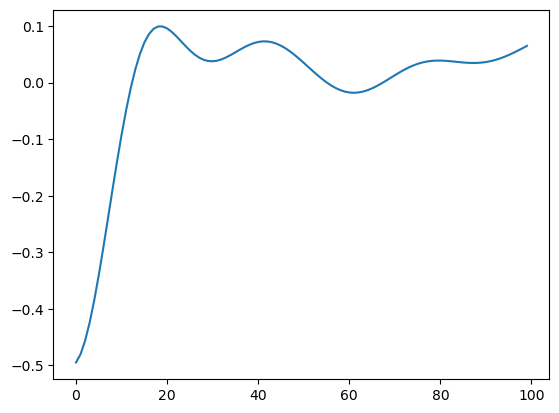

In [4]:
import quante as qt
from quante.bridge.tenpy_utils import (
    tenpy_model_tebd, tenpy_tebd_params_real_time, tenpy_tebd_, set_tenpy_logging
)
import tenpy
op = qt.generate.operas.spin

set_tenpy_logging(level=1)

L = 12
ham = op.heisenberg_operator(L).expandxy(pauli=False)
M = tenpy_model_tebd(
    L=L, oper=ham, pauli=False, conserve='Sz', bc_MPS='finite',
)

psi = tenpy.networks.MPS.from_product_state(
    M.lat.mps_sites(), ["up", "down"]*(L//2)
)

tebd_params = tenpy_tebd_params_real_time(
    dt=0.1,
    order=2,
    chi_max=50,
    svd_min=1.e-10,
    trunc_cut=None,
)

res = []
for t, psi in tenpy_tebd_(psi, M, 10, tebd_params):
    res.append(psi.expectation_value('Sz', 3)[0])

import matplotlib.pyplot as plt
plt.plot(res)

## Finite DMRG

to run finite DMRG, we need

- generate tenpy model by `tenpy_model_mpo`

- set DMRG parameters by `tenpy_dmrg_params`

- run DMRG by `tenpy_dmrg`

In [5]:
import quante as qt
import numpy as np
from quante.bridge.tenpy_utils import (
    tenpy_model_mpo, tenpy_dmrg_params, tenpy_dmrg
)
from tenpy.networks.mps import MPS

L = 10
g = 1.0
op = qt.generate.operas.spin
ham = - op.sum(op.xx(i, i+1) for i in range(L-1)) - g * op.sum(op.z(i) for i in range(L)) + op.xx(1,3)
M = tenpy_model_mpo(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='finite',
)

product_state = ["up"] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)

dmrg_params = tenpy_dmrg_params(
    chi_max=30,
    svd_min=1.e-10,
)

E, _, _ = tenpy_dmrg(psi, M, dmrg_params)  # the main work...

print("E = {E:.13f}".format(E=E))
print("final bond dimensions: ", psi.chi)
mag_x = np.sum(psi.expectation_value("Sigmax"))
mag_z = np.sum(psi.expectation_value("Sigmaz"))
print("magnetization in X = {mag_x:.5f}".format(mag_x=mag_x))
print("magnetization in Z = {mag_z:.5f}".format(mag_z=mag_z))
E_exact = ham.gdenergy(pauli=True)
print("Exact diagonalization: E = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))


TenpyMPOModel: reading 'bc_MPS'='finite'
TenpyMPOModel: reading 'conserve'='None'
TenpyMPOModel: reading 'L'=10
TenpyMPOModel: reading 'oper'=<quante.generate.operas.spin.SpinOper object at 0x0000019936401DF0>
TenpyMPOModel: reading 'pauli'=True
TwoSiteDMRGEngine: reading 'diag_method'='default'
TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
TwoSiteDMRGEngine: subconfig 'lanczos_params'=Config(<0 options>, 'lanczos_params')
TwoSiteDMRGEngine: reading 'chi_list'=None
TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<0 options>, 'mixer_params')
TwoSiteDMRGEngine: reading 'mixer'=None
Running sweep with optimization
trunc_params: reading 'chi_max'=30
trunc_params: reading 'svd_min'=1e-10
checkpoint after sweep 1
energy=-12.3131481871181396, max S=0.3435853527010841, age=10, norm_err=1.8e-02
Current memory usage 221.5MB, wall time: 0.1s
Delta E = nan, Delta S = 2.8498e-01 (per sweep)
max trunc_err = 0.0000e+00, max E_trunc = 1.4211e-14
chi: [2, 4, 4, 4, 4

E = -12.3131598724129
final bond dimensions:  [2, 4, 8, 16, 18, 14, 8, 4, 2]
magnetization in X = 0.00000
magnetization in Z = 7.72189
Exact diagonalization: E = -12.3131598724129
relative error:  1.5869139551400653e-15


## inFinite DMRG

set `bc_MPS` to `infinite` in the model.

In [6]:
import quante as qt
import numpy as np
from quante.bridge.tenpy_utils import (
    tenpy_model_mpo, tenpy_dmrg_params, tenpy_dmrg
)
from tenpy.networks.mps import MPS

op = qt.generate.operas.spin
L = 2
g = 1.5
ham = - op.sum(op.xx(i, i+1) for i in range(L)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_model_mpo(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='infinite',
)

product_state = ["up"] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)

dmrg_params = tenpy_dmrg_params(
    mixer=True,
    chi_max=30,
    svd_min=1.e-10,
    max_E_err=1.e-10,
)
E, psi, _ = tenpy_dmrg(psi, M, dmrg_params)  # the main work...

print("E = {E:.13f}".format(E=E))
print("final bond dimensions: ", psi.chi)
mag_x = np.mean(psi.expectation_value("Sigmax"))
mag_z = np.mean(psi.expectation_value("Sigmaz"))
print("<sigma_x> = {mag_x:.5f}".format(mag_x=mag_x))
print("<sigma_z> = {mag_z:.5f}".format(mag_z=mag_z))
print("correlation length:", psi.correlation_length())
E_exact = qt.generate.operas.spin.heisenberg_operator(L=np.inf, j=(-1.,0,0), h=(0,0,-g)).gdenergy(pauli=True)
print("Analytic result: E(per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))


TenpyMPOModel: reading 'bc_MPS'='infinite'
TenpyMPOModel: reading 'conserve'='None'
TenpyMPOModel: reading 'L'=2
TenpyMPOModel: reading 'oper'=<quante.generate.operas.spin.SpinOper object at 0x00000199363D71D0>
TenpyMPOModel: reading 'pauli'=True
TwoSiteDMRGEngine: reading 'diag_method'='default'
TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
TwoSiteDMRGEngine: subconfig 'lanczos_params'=Config(<0 options>, 'lanczos_params')
TwoSiteDMRGEngine: reading 'chi_list'=None
start environment_sweep
trunc_params: reading 'chi_max'=30
trunc_params: reading 'svd_min'=1e-10
TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<0 options>, 'mixer_params')
TwoSiteDMRGEngine: reading 'mixer'=True
activate DensityMatrixMixer with initial amplitude 1e-05
Running sweep with optimization
start environment_sweep
checkpoint after sweep 10
energy=-1.6719262215362427, max S=0.1534954327561873, age=128, norm_err=9.1e-14
Current memory usage 237.7MB, wall time: 0.5s
Delta E = nan

E = -1.6719262215361
final bond dimensions:  [21, 21]
<sigma_x> = -0.00000
<sigma_z> = 0.87733
correlation length: 2.4113432996820197
Analytic result: E(per site) = -1.6719262215362
relative error:  4.170160444185033e-14


## TDVP

to run TDVP, we need

- generate tenpy model by `tenpy_model_mpo`

- set DMRG parameters by `tenpy_tdvp_params`

- run DMRG by `tenpy_tdvp_`

TenpyMPOModel: reading 'bc_MPS'='finite'
TenpyMPOModel: reading 'conserve'='Sz'
TenpyMPOModel: reading 'L'=12
TenpyMPOModel: reading 'oper'=<quante.generate.operas.spin.SpinOper object at 0x000001992FA8C650>
TenpyMPOModel: reading 'pauli'=False
TwoSiteTDVPEngine: subconfig 'trunc_params'=Config(<1 options>, 'trunc_params')
TwoSiteTDVPEngine: subconfig 'lanczos_params'=Config(<0 options>, 'lanczos_params')
TwoSiteTDVPEngine: reading 'chi_list'={0: 20}
TwoSiteTDVPEngine: reading 'dt'=0.1
Setting chi_max=20
trunc_params: setting 'chi_max'=20
trunc_params: reading 'chi_max'=20
trunc_params: reading 'svd_min'=1e-10
--> time=0.100 + 0.000j, max(chi)=4, max(S)=0.01745, avg DeltaS=1.7430e-02, since last update: 0.2s
--> time=0.200 + 0.000j, max(chi)=10, max(S)=0.05566, avg DeltaS=3.8018e-02, since last update: 0.4s
--> time=0.300 + 0.000j, max(chi)=10, max(S)=0.10619, avg DeltaS=4.9922e-02, since last update: 0.4s
--> time=0.400 + 0.000j, max(chi)=13, max(S)=0.16417, avg DeltaS=5.6791e-02, sin

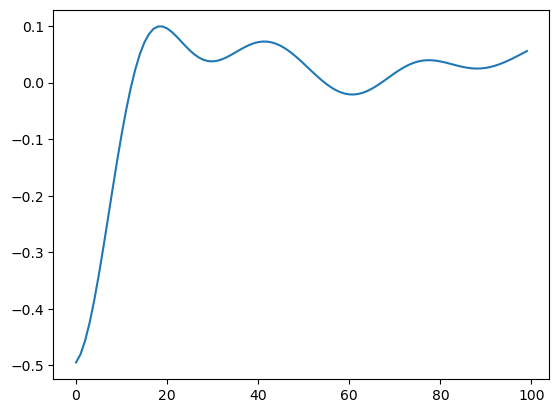

In [7]:
import quante as qt
op = qt.generate.operas.spin

from quante.bridge.tenpy_utils import (
    tenpy_model_mpo, tenpy_tdvp_params, tenpy_tdvp_
)
import matplotlib.pyplot as plt


L = 12
chi = 20  # exemplary strong truncation!
delta_t = 0.1

ham = op.heisenberg_operator(L).expandxy(pauli=False)
M = tenpy_model_mpo(
    L=L, oper=ham, pauli=False, conserve='Sz', bc_MPS='finite',
)

psi = tenpy.networks.MPS.from_product_state(
    M.lat.mps_sites(), ["up", "down"]*(L//2)
)

tdvp_params = tenpy_tdvp_params(
    dt=delta_t,
    chi_list={0: chi},
    svd_min=1.e-10,
)

res = []
for t, psi in tenpy_tdvp_(psi, M, 10, tdvp_params, progressbar=False):
    res.append(psi.expectation_value('Sz', 3)[0])

import matplotlib.pyplot as plt
plt.plot(res)
